In [2]:
pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ---------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/lifestyle-and-health-risk-prediction")

print("Path to dataset files:", path)

c:\Users\visha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 59.7k/59.7k [00:00<00:00, 125kB/s]

Extracting files...
Path to dataset files: C:\Users\visha\.cache\kagglehub\datasets\miadul\lifestyle-and-health-risk-prediction\versions\1


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

# 1. Provide your local path here
file_path = "C:/Users/visha/.cache/kagglehub/datasets/miadul/lifestyle-and-health-risk-prediction/versions/1/Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv" 

# 2. Load and Clean
df = pd.read_csv(file_path)

# Turn words into numbers (Encoding)
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 3. Train Model
# Target is 'health_risk' in the Miadul dataset
X = df.drop('health_risk', axis=1) 
y = df['health_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Save the model to your local folder
joblib.dump(model, 'health_risk_model.pkl')
print("✅ Model trained and saved as 'health_risk_model.pkl'")

✅ Model trained and saved as 'health_risk_model.pkl'


In [10]:
import joblib
import pandas as pd

# 1. Load the model
model = joblib.load('health_risk_model.pkl')

# 2. Create a test scenario 
# IMPORTANT: These must be in the same order as your CSV columns!
# Example: age, weight, height, exercise, sleep, sugar, smoking, alcohol, married, profession, bmi
test_data = pd.DataFrame([{
    'age': 30,
    'weight': 75.0,
    'height': 170,
    'exercise': 2,        # Medium
    'sleep': 8,           # Hours
    'sugar_intake': 1,    # Low
    'smoking': 0,         # No
    'alcohol': 0,         # No
    'married': 0,         # No
    'profession': 10,     # Category number
    'bmi': 25.9
}])

# 3. Predict
prediction = model.predict(test_data)[0]
risk_chance = model.predict_proba(test_data)[0][1] # Probability of High Risk

print("--- Prediction Result ---")
if prediction == 1:
    print(f"Result: HIGH Risk ({risk_chance*100:.2f}%)")
else:
    print(f"Result: LOW Risk ({risk_chance*100:.2f}%)")

--- Prediction Result ---
Result: HIGH Risk (72.00%)


age: 26.52%
weight: 8.07%
height: 5.01%
exercise: 10.56%
sleep: 8.27%
sugar_intake: 5.60%
smoking: 8.98%
alcohol: 5.13%
married: 0.66%
profession: 2.02%
bmi: 19.18%


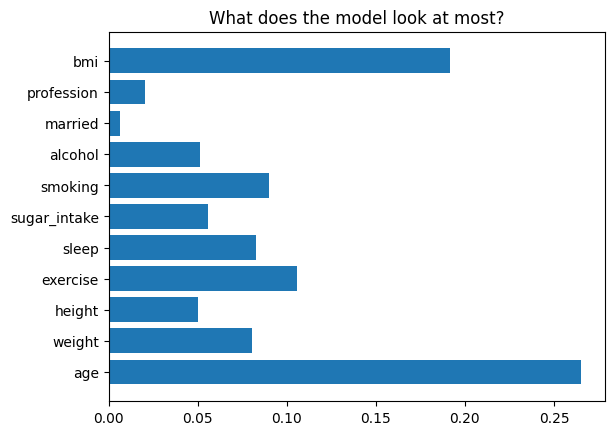

In [11]:
import matplotlib.pyplot as plt

# Get importance levels from the model
importances = model.feature_importances_
feature_names = X.columns

# Print them out
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance*100:.2f}%")

# Plot it for a better view
plt.barh(feature_names, importances)
plt.title("What does the model look at most?")
plt.show()